# Surface Defect Detection — AI Quality Assurance System
**ResNet-50 Transfer Learning | MVTec AD Dataset | Binary Classification**

---

Built as part of a 6-week internship project for a ceramic tile manufacturing company.
The system classifies tile surface images as **Normal** or **Defective** using a fine-tuned
ResNet-50 model trained on industrial inspection data.

### Dataset
[MVTec Anomaly Detection](https://www.mvtec.com/company/research/datasets/mvtec-ad) —
flat-surface texture pattern categories only: `tile`, `carpet`, `leather`, `wood`.
These share the same imaging geometry (top-down, controlled lighting) as real factory inspection.
3D object categories (screws, pills, cables) were excluded — their defect morphology
has no relevance to surface crack detection.

### Model
| Property | Value |
|---|---|
| Architecture | ResNet-50 pretrained on ImageNet (IMAGENET1K_V2) |
| Fine-tuned layers | layer3, layer4, classification head |
| Input resolution | 384 × 384 RGB |
| Output | Normal / Defective + confidence score |
| Classes | Defective → index 0 · Normal → index 1 |

### Key Design Decisions
- **Per-class augmentation** — heavy rotation and affine transforms on Defective only,
  mild flips on Normal. Keeps the clean-surface signal stable while multiplying rare defect examples.
- **WeightedRandomSampler** — balances batches at ~50/50 despite a 4:1 folder imbalance.
- **Dual loss functions** — weighted CrossEntropyLoss for training, unweighted for validation.
  Prevents inflated val_loss from triggering early stopping prematurely.
- **Grid category excluded** — grayscale images; PIL RGB conversion produces flat R=G=B tensors
  that destabilise ResNet's colour-sensitive feature maps from epoch 1.

### Primary Metric
**Defective recall** — of all actually defective tiles in the test set, what fraction did the model flag?
Overall accuracy is tracked but not the decision metric. In manufacturing QA, a missed defect
reaching a customer costs far more than a false alarm slowing the line.

In [ ]:
# CELL 1 — Mount Drive and extract the dataset
import os
import zipfile
from google.colab import drive

drive.mount('/content/drive')

# Archive path and extraction path
zip_path     = '/content/drive/MyDrive/mvtec_tile.zip'
extract_path = '/content/'

print(f"Extracting {zip_path} ...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete!")

BASE = '/content/mvtec_tile/full_mvtec'

# Confirm folder structure and image counts extracted correctly
print("--- Verifying Folders ---")
for split in ['Train_resized', 'Test_resized']:
    for category in ['Normal', 'Defective']:
        path = os.path.join(BASE, split, category)
        count = len(os.listdir(path)) if os.path.exists(path) else 'NOT FOUND'
        print(f"  {split}/{category}: {count} images")

# Breakdown by original MVTec source category, inferred from filename prefixes
print("--- Source category breakdown (Train/Defective) ---")
defective_path = os.path.join(BASE, 'Train_resized', 'Defective')
if os.path.exists(defective_path):
    from collections import Counter
    cats = Counter(f.split("_")[0] for f in os.listdir(defective_path))
    for cat, count in sorted(cats.items()):
        print(f"  {cat:<15}: {count} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting /content/drive/MyDrive/mvtec_tile.zip ...
Extraction complete!
--- Verifying Folders ---
  Train_resized/Normal: 1030 images
  Train_resized/Defective: 264 images
  Test_resized/Normal: 278 images
  Test_resized/Defective: 117 images
--- Source category breakdown (Train/Defective) ---
  carpet         : 62 images
  grid           : 39 images
  leather        : 63 images
  tile           : 58 images
  wood           : 42 images


In [16]:
# CELL 2 — Device check
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [17]:
# CELL 3 — Remove grid images and compute class weights
#
# Grid tiles are grayscale, which confuses a ResNet trained on color
# features, so they're excluded from both the train and test sets
# before we compute the class balance.
import os, shutil
import torch

BASE = '/content/mvtec_tile/full_mvtec'
train_defective_path = os.path.join(BASE, 'Train_resized', 'Defective')
test_defective_path  = os.path.join(BASE, 'Test_resized',  'Defective')

# Drop grid images from the defective set (grayscale, excluded from training)
removed = 0
for folder in [train_defective_path, test_defective_path]:
    if not os.path.exists(folder): continue
    for fname in os.listdir(folder):
        if fname.startswith('grid_'):
            os.remove(os.path.join(folder, fname))
            removed += 1
print(f"Removed {removed} grid images (grayscale — excluded from training)")

train_normal_path    = os.path.join(BASE, 'Train_resized', 'Normal')
n_normal    = len([f for f in os.listdir(train_normal_path) if not f.startswith('grid_')])
n_defective = len(os.listdir(train_defective_path))
n_total     = n_normal + n_defective

print(f"Train Normal    : {n_normal}")
print(f"Train Defective : {n_defective}")
print(f"Imbalance ratio : {n_normal/n_defective:.1f}:1")

# Inverse-frequency weighting so the loss penalizes both classes equally
weight_defective = n_total / (2 * n_defective)
weight_normal    = n_total / (2 * n_normal)
class_weights = torch.tensor([weight_defective, weight_normal], dtype=torch.float32).to(device)

print(f"CrossEntropyLoss weights:")
print(f"  Defective (idx 0): {weight_defective:.4f}")
print(f"  Normal    (idx 1): {weight_normal:.4f}")

Removed 57 grid images (grayscale — excluded from training)
Train Normal    : 815
Train Defective : 225
Imbalance ratio : 3.6:1
CrossEntropyLoss weights:
  Defective (idx 0): 2.3111
  Normal    (idx 1): 0.6380


In [18]:
# CELL 4 — Transforms, dataset, and sampler
#
# Normal and Defective images get different augmentation strengths, and
# the sampler oversamples the minority (Defective) class per epoch so
# the model sees a roughly balanced batch composition during training.
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
from collections import Counter

TARGET_SIZE   = (384, 384)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Normal surfaces: light augmentation, since defects aren't the focus here
normal_transform = transforms.Compose([
    transforms.Resize(TARGET_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Defective surfaces: moderate augmentation. Kept deliberately conservative —
# aggressive perspective/color warps can distort defect patterns to the
# point the model starts learning augmentation artifacts instead of real
# defects. Rotation is left unrestricted since a crack is still a crack
# at any angle.
defective_transform = transforms.Compose([
    transforms.Resize(TARGET_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Test/inference: no augmentation, just resize + normalize
test_transform = transforms.Compose([
    transforms.Resize(TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


class SurfaceDataset(Dataset):
    CLASS_TO_IDX = {'Defective': 0, 'Normal': 1}

    def __init__(self, root, class_transforms):
        self.root             = root
        self.class_transforms = class_transforms
        self.class_to_idx     = self.CLASS_TO_IDX
        self.classes          = list(self.CLASS_TO_IDX.keys())
        self.samples          = []

        for class_name, class_idx in self.CLASS_TO_IDX.items():
            folder = os.path.join(root, class_name)
            if not os.path.exists(folder):
                print(f"WARNING: {folder} not found")
                continue
            for fname in sorted(os.listdir(folder)):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(folder, fname), class_idx, class_name))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, class_name = self.samples[idx]
        image = Image.open(path).convert('RGB')
        transform = self.class_transforms.get(class_name)
        if transform:
            image = transform(image)
        return image, label


BASE = '/content/mvtec_tile/full_mvtec'

train_dataset = SurfaceDataset(
    root = os.path.join(BASE, 'Train_resized'),
    class_transforms = {'Normal': normal_transform, 'Defective': defective_transform}
)
test_dataset = SurfaceDataset(
    root = os.path.join(BASE, 'Test_resized'),
    class_transforms = {'Normal': test_transform, 'Defective': test_transform}
)

label_counts = Counter(s[1] for s in train_dataset.samples)
n_def = label_counts[0]
n_nor = label_counts[1]
n_total_train = len(train_dataset.samples)

print(f"Train samples : {len(train_dataset)} (Normal: {n_nor}, Defective: {n_def})")
print(f"Test  samples : {len(test_dataset)}")
print(f"class_to_idx  : {train_dataset.class_to_idx}")

# WeightedRandomSampler draws Defective images more often than their raw
# count would suggest, so each epoch sees a roughly even class split.
# num_samples is capped at n_nor rather than 2*n_nor, which keeps each
# Defective image appearing ~4x per epoch instead of ~8x — enough to
# balance the classes without the model memorizing repeated augmentations.
train_labels = [s[1] for s in train_dataset.samples]
class_weight_map = {
    0: n_total_train / n_def,
    1: n_total_train / n_nor,
}
sample_weights = torch.tensor([class_weight_map[l] for l in train_labels], dtype=torch.float)

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = n_nor,
    replacement = True
)

BATCH_SIZE = 16   # smaller batch size gives a cleaner gradient signal on this dataset size

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"Train batches : {len(train_loader)} (batch size: {BATCH_SIZE})")
print(f"Test  batches : {len(test_loader)}")
print(f"Samples/epoch : {n_nor} (~{n_nor//2} per class)")

# Quick sanity check that the sampler is actually balancing batches
print("Batch balance (first 3 batches):")
for i, (_, labels) in enumerate(train_loader):
    c = Counter(labels.numpy())
    print(f"  Batch {i+1}: Defective={c.get(0,0)}, Normal={c.get(1,0)}")
    if i == 2: break

Train samples : 1255 (Normal: 1030, Defective: 225)
Test  samples : 377
class_to_idx  : {'Defective': 0, 'Normal': 1}
Train batches : 65 (batch size: 16)
Test  batches : 24
Samples/epoch : 1030 (~515 per class)
Batch balance (first 3 batches):
  Batch 1: Defective=5, Normal=11
  Batch 2: Defective=8, Normal=8
  Batch 3: Defective=9, Normal=7


In [19]:
# CELL 5 — Build the ResNet-50 model
import torchvision.models as models
import torch.nn as nn

def build_resnet50_model(num_classes=2, freeze_base=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    if freeze_base:
        # Freeze the full backbone, then unfreeze the last two residual
        # blocks so the model can adapt mid-to-high level features to
        # surface defects instead of only retraining the classifier head.
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer3.parameters():
            param.requires_grad = True
        for param in model.layer4.parameters():
            param.requires_grad = True

    in_features = model.fc.in_features  # 2048 for ResNet-50
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_resnet50_model().to(device)

# Confirm how much of the network is actually being fine-tuned
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,} / {total:,} total")

Trainable params : 22,067,202 / 23,512,130 total


In [21]:
# CELL 6 — Loss, optimizer, scheduler
#
# Two separate loss functions are used: a class-weighted criterion for
# training (so the model doesn't just default to predicting the majority
# class), and an unweighted one purely for validation, since a weighted
# validation loss would look artificially high and trip early stopping
# before the model has actually converged.
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn

# Training loss: weighted — penalizes missed Defective predictions more heavily
criterion      = nn.CrossEntropyLoss(weight=class_weights)

# Validation loss: unweighted — gives a comparable, honest val_loss per epoch
# that early stopping can rely on
criterion_val  = nn.CrossEntropyLoss()

# Discriminative learning rates: earlier layers get smaller updates since
# they already encode general features, while the classifier head trains
# faster since it starts from random init
optimizer = Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    {'params': model.layer4.parameters(), 'lr': 5e-5},
    {'params': model.fc.parameters(),     'lr': 2e-4},
])

scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4)

print("Training criterion : CrossEntropyLoss (weighted) — penalizes missed defects")
print("Validation criterion: CrossEntropyLoss (unweighted) — honest early stopping")
print("Optimizer LR: layer3=1e-5 | layer4=5e-5 | fc=2e-4")

Training criterion : CrossEntropyLoss (weighted) — penalizes missed defects
Validation criterion: CrossEntropyLoss (unweighted) — honest early stopping
Optimizer LR: layer3=1e-5 | layer4=5e-5 | fc=2e-4


In [22]:
# CELL 7 — Training loop
#
# Tracks train/val loss, accuracy, F1, and defect recall each epoch, and
# checkpoints the model whenever validation loss improves. Early stopping
# uses a patience of 12 epochs to give the model enough room to converge
# before halting.
import torch
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, recall_score

def train_model(model, train_loader, test_loader,
                criterion, criterion_val, optimizer, scheduler, epochs=50):

    best_val_loss    = float('inf')
    patience_counter = 0
    PATIENCE = 12

    history = {
        'train_loss'   : [],
        'val_loss'     : [],
        'val_acc'      : [],
        'val_f1'       : [],
        'defect_recall': [],
    }

    for epoch in range(epochs):
        # --- Training pass (weighted criterion) ---
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)   # weighted
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)

        # --- Validation pass (unweighted criterion) ---
        model.eval()
        val_running_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion_val(outputs, labels)  # unweighted
                val_running_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss  = val_running_loss / len(test_loader)
        val_acc       = accuracy_score(all_labels, all_preds)
        val_f1        = f1_score(all_labels, all_preds, average='weighted')
        defect_recall = recall_score(all_labels, all_preds, pos_label=0, zero_division=0)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['defect_recall'].append(defect_recall)

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train: {avg_train_loss:.4f} | "
              f"Val: {avg_val_loss:.4f} | "
              f"Acc: {val_acc:.3f} | "
              f"F1: {val_f1:.3f} | "
              f"Defect Recall: {defect_recall:.3f}")

        scheduler.step(avg_val_loss)

        # Checkpoint on best validation loss; stop once patience runs out
        if avg_val_loss < best_val_loss:
            best_val_loss    = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), '/content/drive/MyDrive/best_model_mvtec.pth')
            print(f"   ✓ Saved  (defect recall: {defect_recall:.3f})")
        else:
            patience_counter += 1
            print(f"   Patience: {patience_counter}/{PATIENCE}")
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return history


print("Starting training...")
history = train_model(
    model, train_loader, test_loader,
    criterion, criterion_val,
    optimizer, scheduler,
    epochs=50
)
print("Training complete!")

Starting training...
Epoch [01/50] Train: 0.3129 | Val: 0.4491 | Acc: 0.767 | F1: 0.689 | Defect Recall: 0.111
   ✓ Saved  (defect recall: 0.111)
Epoch [02/50] Train: 0.1037 | Val: 0.4879 | Acc: 0.767 | F1: 0.689 | Defect Recall: 0.111
   Patience: 1/12
Epoch [03/50] Train: 0.0710 | Val: 0.6054 | Acc: 0.777 | F1: 0.710 | Defect Recall: 0.152
   Patience: 2/12
Epoch [04/50] Train: 0.0786 | Val: 0.3680 | Acc: 0.812 | F1: 0.774 | Defect Recall: 0.303
   ✓ Saved  (defect recall: 0.303)
Epoch [05/50] Train: 0.0440 | Val: 0.4666 | Acc: 0.806 | F1: 0.765 | Defect Recall: 0.283
   Patience: 1/12
Epoch [06/50] Train: 0.0360 | Val: 0.3447 | Acc: 0.849 | F1: 0.825 | Defect Recall: 0.424
   ✓ Saved  (defect recall: 0.424)
Epoch [07/50] Train: 0.0414 | Val: 0.3793 | Acc: 0.846 | F1: 0.822 | Defect Recall: 0.414
   Patience: 1/12
Epoch [08/50] Train: 0.0212 | Val: 0.3827 | Acc: 0.862 | F1: 0.843 | Defect Recall: 0.475
   Patience: 2/12
Epoch [09/50] Train: 0.0150 | Val: 0.5408 | Acc: 0.830 | F1: 0.7

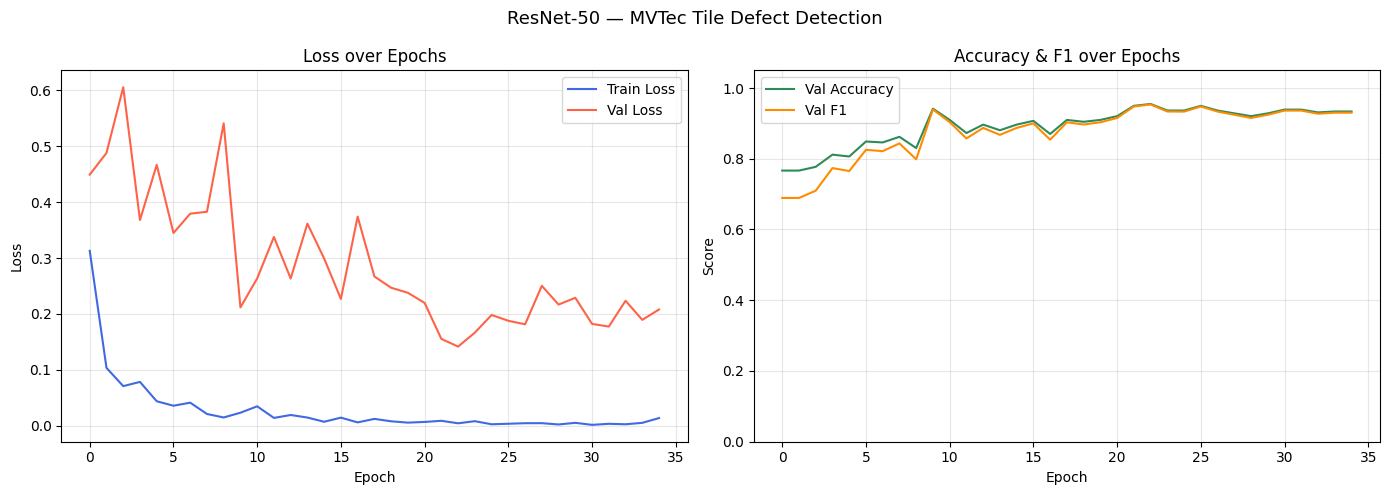

Saved to Drive.


In [23]:
# CELL 8 — Plot learning curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy and F1
axes[1].plot(history['val_acc'], label='Val Accuracy', color='seagreen')
axes[1].plot(history['val_f1'],  label='Val F1',       color='darkorange')
axes[1].set_title('Accuracy & F1 over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1.05])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ResNet-50 — MVTec Tile Defect Detection', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/learning_curves_mvtec.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive.")

Prediction distribution: Counter({np.int64(1): 295, np.int64(0): 82})
True label distribution: Counter({np.int64(1): 278, np.int64(0): 99})

              precision    recall  f1-score   support

   Defective       1.00      0.83      0.91        99
      Normal       0.94      1.00      0.97       278

    accuracy                           0.95       377
   macro avg       0.97      0.91      0.94       377
weighted avg       0.96      0.95      0.95       377



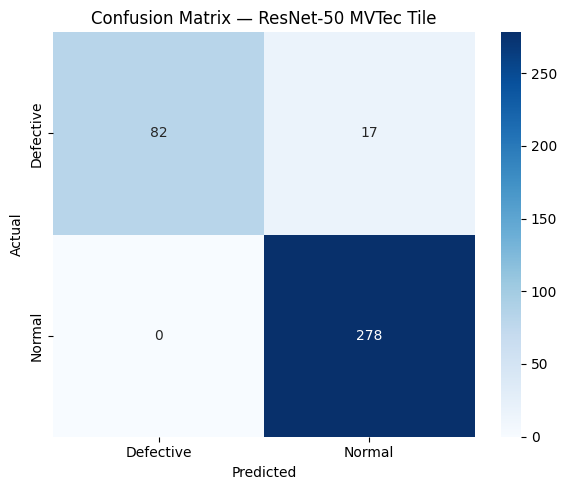

Saved to Drive.


In [24]:
# CELL 9 — Full evaluation with confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reload the best checkpoint rather than relying on the model's state
# at the end of training, since early stopping may have run past it
model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_mvtec.pth', map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Sanity check: predicted vs. true class distribution should roughly line up
print("Prediction distribution:", Counter(all_preds))
print("True label distribution:", Counter(all_labels))
print()

# Defective recall is the number that matters most for a QA system —
# missed defects are far costlier than false alarms
print(classification_report(
    all_labels, all_preds,
    target_names=train_dataset.classes  # ['Defective', 'Normal']
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes,
    cmap='Blues'
)
plt.title('Confusion Matrix — ResNet-50 MVTec Tile')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_mvtec.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive.")